First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

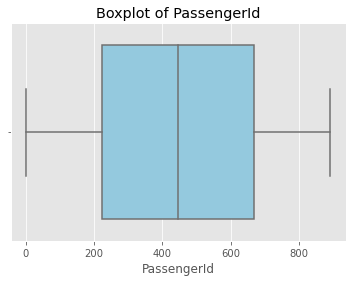

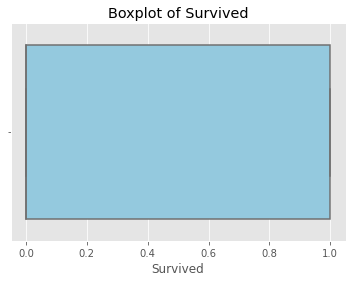

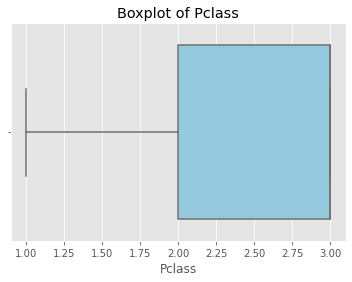

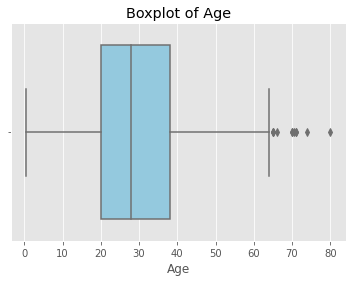

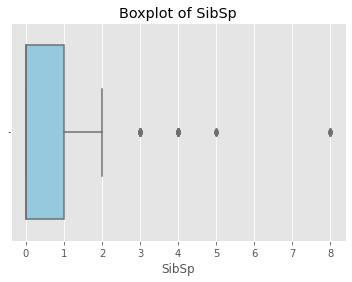

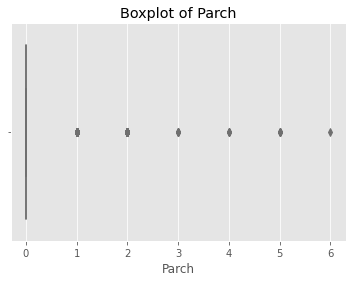

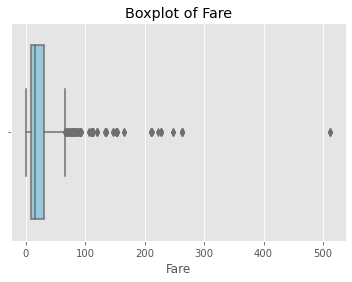

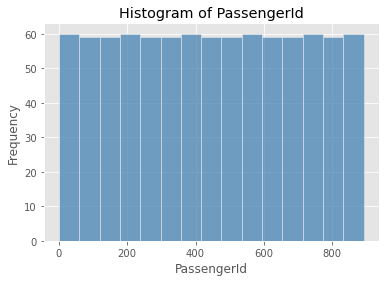

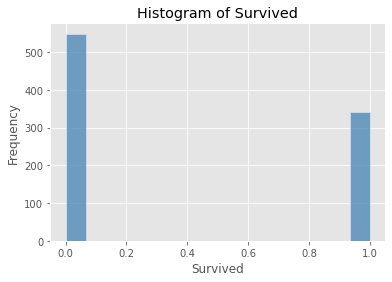

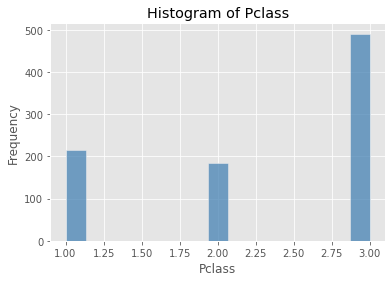

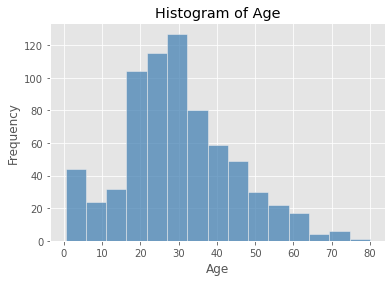

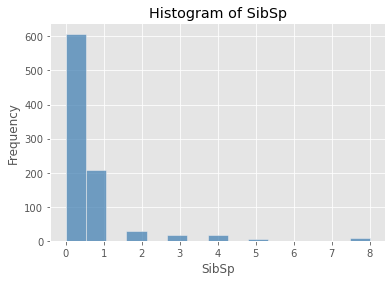

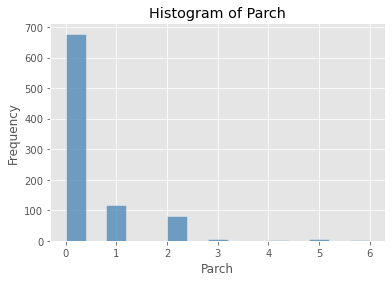

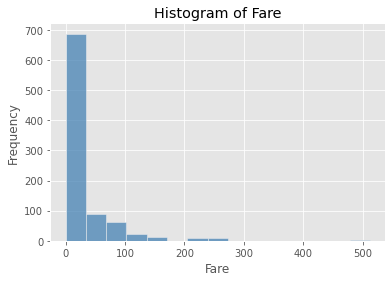

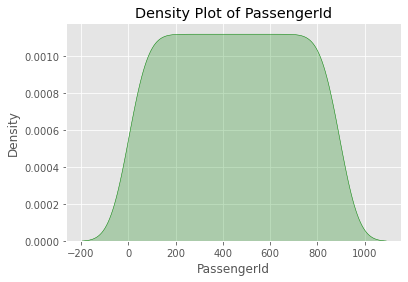

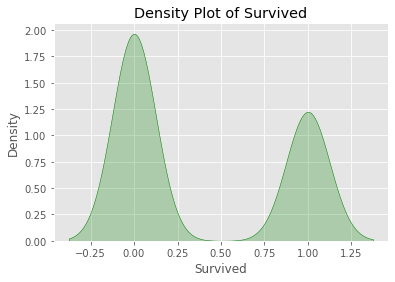

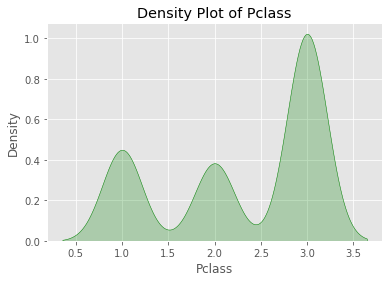

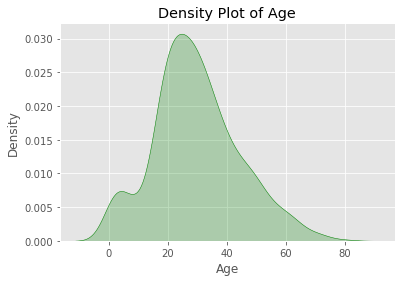

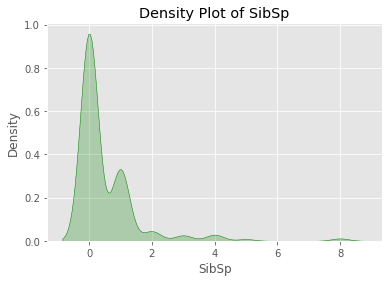

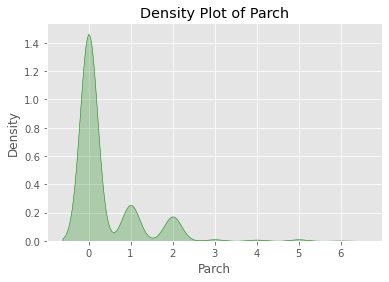

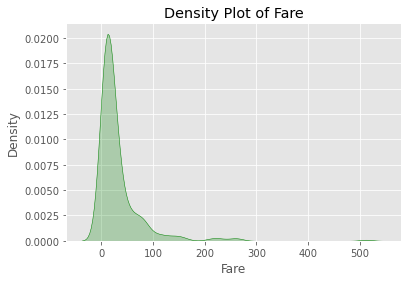

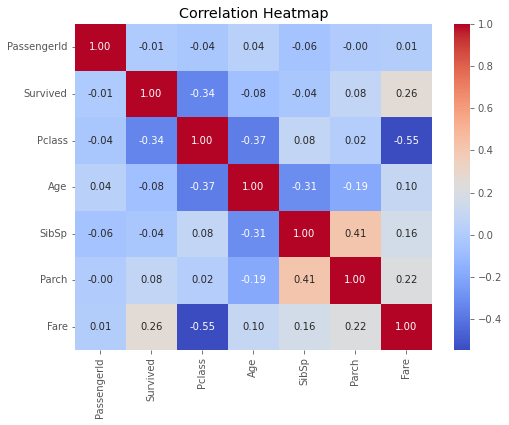

In [ ]:
!pip install pandas numpy scipy matplotlib seaborn




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation
from scipy.stats import probplot

plt.style.use('ggplot')






df = pd.read_csv("titanic.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())






num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)









for col in num_df.columns:
    print(f"{col} Mean:", num_df[col].mean())




for col in num_df.columns:
    print(f"{col} Median:", num_df[col].median())






for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col} Trimmed Mean:", trim_mean(data, 0.10))




for col in num_df.columns:
    data = num_df[col].dropna()
    weights = np.arange(1, len(data)+1)
    print(f"{col} Weighted Mean:", np.average(data, weights=weights))





for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col} Range:", data.max() - data.min())






for col in num_df.columns:
    print(f"{col} Variance:", num_df[col].var())



for col in num_df.columns:
    print(f"{col} Standard Deviation:", num_df[col].std())





for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    print(f"{col} IQR:", Q3 - Q1)




for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col} MAD:", median_abs_deviation(data))



for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col} MAD:", median_abs_deviation(data))




for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.show()





for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=15, color="steelblue")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()





for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col].dropna(), fill=True, color="green")
    plt.title(f"Density Plot of {col}")
    plt.show()






plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()










if "Survived" in df.columns:
    sns.pairplot(df, hue="Survived")
else:
    sns.pairplot(num_df)

plt.show()





for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
    plt.show()






if "Survived" in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="Survived", data=df)
    plt.title("Survival Distribution")
    plt.show()






print("Analysis Completed Successfully!")









